In [1]:
import SimpleITK as sitk
import numpy as np
from morphometry.utils import correct_axis_ordering, read_nifti
from matplotlib import pyplot as plt

In [2]:
# image = sitk.ReadImage('/home/simon/Downloads/Patienten Set1/Pat1/image.nii.gz')
# femur_left = sitk.ReadImage('/home/simon/Downloads/Patienten Set1/Pat1/segments/femur_left.nii.gz')
# femur_right = sitk.ReadImage('/home/simon/Downloads/Patienten Set1/Pat1/segments/femur_right.nii.gz')
# tibia = sitk.ReadImage('/home/simon/Downloads/Patienten Set1/Pat1/segments/tibia.nii.gz')
# fibula = sitk.ReadImage('/home/simon/Downloads/Patienten Set1/Pat1/segments/fibula.nii.gz')
image = read_nifti('/home/simon/Downloads/Patienten Set1/Pat1/image.nii.gz')
femur_left = read_nifti('/home/simon/Downloads/Patienten Set1/Pat1/segments/femur_left.nii.gz')
femur_right = read_nifti('/home/simon/Downloads/Patienten Set1/Pat1/segments/femur_right.nii.gz')
tibia = read_nifti('/home/simon/Downloads/Patienten Set1/Pat1/segments/tibia.nii.gz')
fibula = read_nifti('/home/simon/Downloads/Patienten Set1/Pat1/segments/fibula.nii.gz')

In [3]:
# image = correct_axis_ordering(image)
# femur_left = correct_axis_ordering(femur_left)
# femur_right = correct_axis_ordering(femur_right)
# tibia = correct_axis_ordering(tibia)
# fibula = correct_axis_ordering(fibula)

In [4]:
image.GetSpacing()

(0.699999988079071, 0.734375, 0.734375)

In [11]:
image.GetSize()

(512, 512, 1916)

**Note:** Femur left/right refers to patient side!

In [5]:
image_array = sitk.GetArrayFromImage(image)
femur_left_array = sitk.GetArrayFromImage(femur_left)
femur_right_array = sitk.GetArrayFromImage(femur_right)
tibia_array = sitk.GetArrayFromImage(tibia)
fibula_array = sitk.GetArrayFromImage(fibula)

In [10]:
image_array.shape

(1916, 512, 512)

In [6]:
femur_array = femur_left_array + femur_right_array

In [7]:
np.unique(femur_array)

array([0., 1.])

In [8]:
np.unique(tibia_array)

array([0., 1.])

In [9]:
np.unique(fibula_array)

array([0., 1.])

In [12]:
femur_most_proximal = np.min(np.argwhere(femur_array == 1)[:, 0])
femur_most_distal = np.max(np.argwhere(femur_array == 1)[:, 0])
tibia_most_proximal = np.min(np.argwhere(tibia_array == 1)[:, 0])
tibia_most_distal = np.max(np.argwhere(tibia_array == 1)[:, 0])
fibula_most_proximal = np.min(np.argwhere(fibula_array == 1)[:, 0])
fibula_most_distal = np.max(np.argwhere(fibula_array == 1)[:, 0])

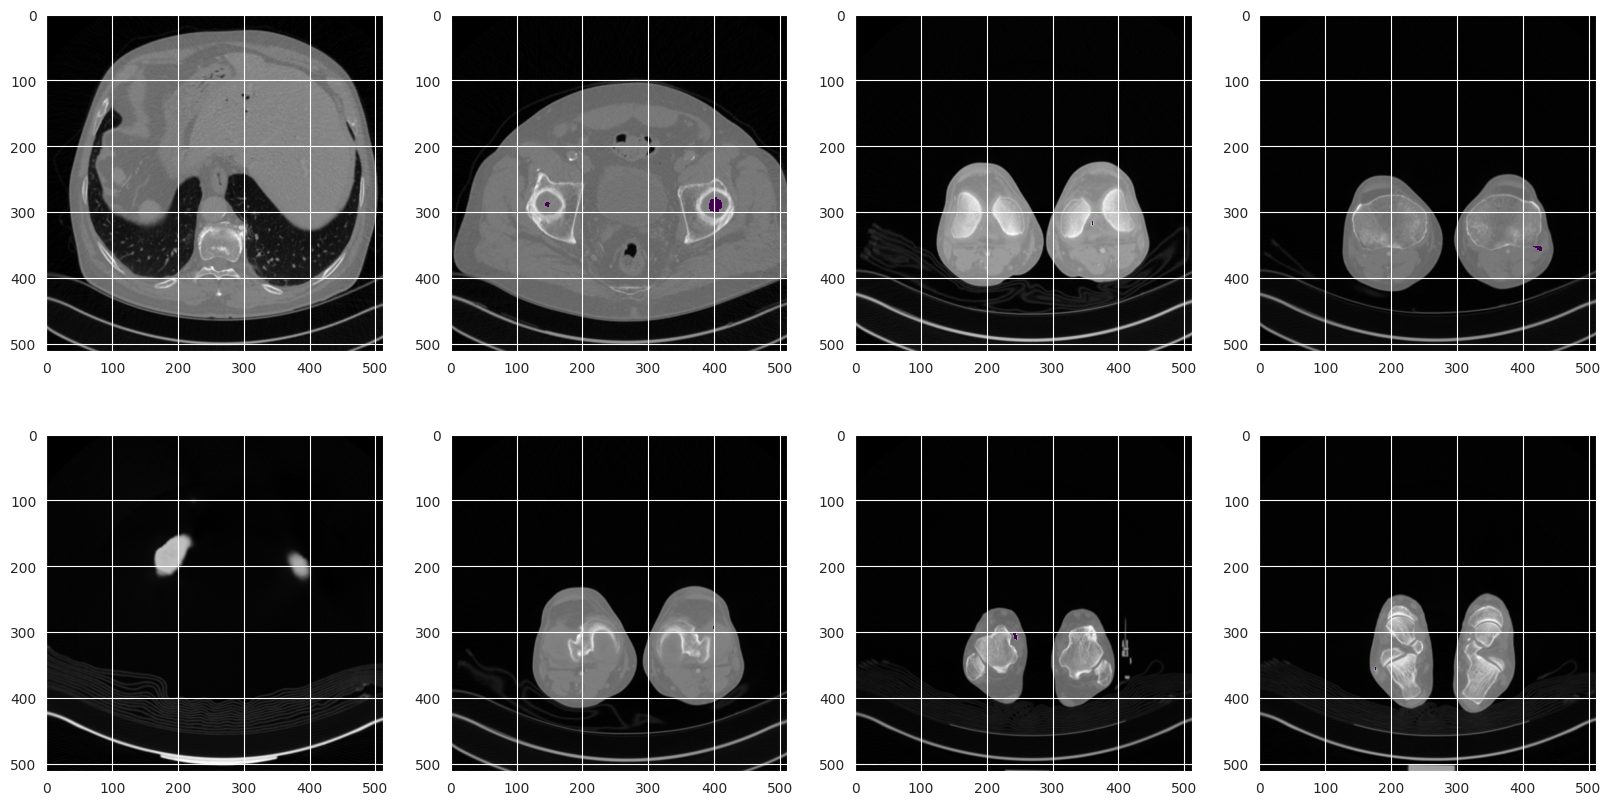

In [13]:
fig, ax = plt.subplots(2, 4, figsize=(20, 10))
ax[0, 0].imshow(image_array[0], cmap='gray')
ax[1, 0].imshow(image_array[-1], cmap='gray')
ax[0, 1].imshow(image_array[femur_most_proximal], cmap='gray')
ax[0, 1].imshow(np.where(femur_array[femur_most_proximal] == 0, np.nan, 1), cmap='viridis')
ax[1, 1].imshow(image_array[femur_most_distal], cmap='gray')
ax[1, 1].imshow(np.where(femur_array[femur_most_distal] == 0, np.nan, 1), cmap='viridis')
ax[0, 2].imshow(image_array[tibia_most_proximal], cmap='gray')
ax[0, 2].imshow(np.where(tibia_array[tibia_most_proximal] == 0, np.nan, 1), cmap='viridis')
ax[1, 2].imshow(image_array[tibia_most_distal], cmap='gray')
ax[1, 2].imshow(np.where(tibia_array[tibia_most_distal] == 0, np.nan, 1), cmap='viridis')
ax[0, 3].imshow(image_array[fibula_most_proximal], cmap='gray')
ax[0, 3].imshow(np.where(fibula_array[fibula_most_proximal] == 0, np.nan, 1), cmap='viridis')
ax[1, 3].imshow(image_array[fibula_most_distal], cmap='gray')
ax[1, 3].imshow(np.where(fibula_array[fibula_most_distal] == 0, np.nan, 1), cmap='viridis')
plt.show()

Axis ordering should be ok:
- anterior - posterior : small - large
- superior - inferior : small - large
- left patient side - right image side

In [14]:
femur_split = (femur_most_distal - femur_most_proximal) // 2
tibia_split = (tibia_most_distal - tibia_most_proximal) // 2
fibula_split = (fibula_most_distal - fibula_most_proximal) // 2

In [15]:
femur_most_proximal, femur_most_distal, femur_split

(482, 1167, 342)

In [16]:
tibia_most_proximal, tibia_most_distal, tibia_split

(1155, 1733, 289)

In [17]:
fibula_most_proximal, fibula_most_distal, fibula_split

(1187, 1757, 285)

In [18]:
proximal_femur = femur_array[femur_most_proximal:femur_most_proximal + femur_split]
distal_femur = femur_array[femur_most_proximal + femur_split:femur_most_distal]
proximal_tibia = tibia_array[tibia_most_proximal:tibia_most_proximal + tibia_split]
distal_tibia = tibia_array[tibia_most_proximal + tibia_split:max(tibia_most_distal, fibula_most_distal)]
distal_fibula = fibula_array[tibia_most_proximal + tibia_split:max(tibia_most_distal, fibula_most_distal)]

In [19]:
hip = proximal_femur
knee = np.vstack((distal_femur, np.where(proximal_tibia == 1, 2, 0)))
ankle = distal_tibia + np.where(distal_fibula == 1, 2, 0)

In [20]:
hip.shape, knee.shape, ankle.shape

((342, 512, 512), (632, 512, 512), (313, 512, 512))

In [21]:
np.unique(ankle)

array([0., 1., 2.])

In [22]:
h = sitk.GetImageFromArray(hip)
k = sitk.GetImageFromArray(knee)
a = sitk.GetImageFromArray(ankle)
sitk.WriteImage(h, '/home/simon/Downloads/Patienten Set1/Pat1/hip.nii.gz')
sitk.WriteImage(k, '/home/simon/Downloads/Patienten Set1/Pat1/knee.nii.gz')
sitk.WriteImage(a, '/home/simon/Downloads/Patienten Set1/Pat1/ankle.nii.gz')

Looks good so far...

In [23]:
from typing import Tuple
from scipy.ndimage import label as scipy_label
from scipy.ndimage import center_of_mass

def split_masks(segmentation_mask: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    Split a segmentation mask into two separate masks, one for the left and one for the right bone.
    :param segmentation_mask: A 3D segmentation mask.
    :return:
    """
    # Step 1: Label connected components
    labels, num_features = scipy_label(segmentation_mask)

    # Step 2: Compute properties of each component
    components = []
    for i in range(1, num_features + 1):
        # Compute volume
        volume = np.sum(labels == i)
        # Compute centroid
        centroid = center_of_mass(segmentation_mask, labels, i)
        components.append({'label': i, 'volume': volume, 'centroid': centroid})

    # Step 3: Identify the two largest components
    components.sort(key=lambda x: x['volume'], reverse=True)
    bone_1 = components[0]
    bone_2 = components[1]

    # Step 4: Determine which bone is left and which is right
    # Adjust the index [2] if the left-right axis is not the first axis
    if bone_1['centroid'][2] < bone_2['centroid'][2]:
        left_label = bone_1['label']
        right_label = bone_2['label']
    else:
        left_label = bone_2['label']
        right_label = bone_1['label']

    # Step 5: Create separate masks
    left_mask = (labels == left_label)
    right_mask = (labels == right_label)

    return left_mask.astype(np.uint8), right_mask.astype(np.uint8)

In [24]:
left_hip, right_hip = split_masks(hip)

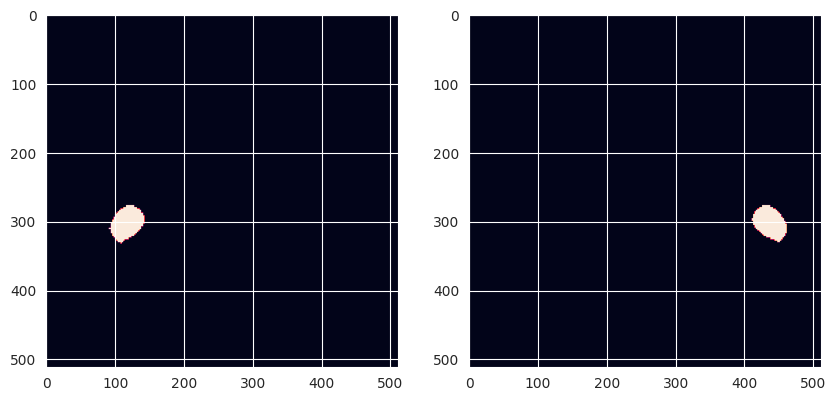

In [25]:
fig, ax = plt.subplots(ncols=2, figsize=(10, 5))
ax[0].imshow(left_hip[left_hip.shape[0]//2])
ax[1].imshow(right_hip[right_hip.shape[0]//2])
plt.show()

In [26]:
left_knee_femur, right_knee_femur = split_masks(np.where(knee == 1, 1, 0))
left_knee_tibia, right_knee_tibia = split_masks(np.where(knee == 2, 1, 0))
left_knee = left_knee_femur + np.where(left_knee_tibia == 1, 2, 0)
right_knee = right_knee_femur + np.where(right_knee_tibia == 1, 2, 0)

In [27]:
np.unique(left_knee), np.unique(right_knee)

(array([0, 1, 2]), array([0, 1, 2]))

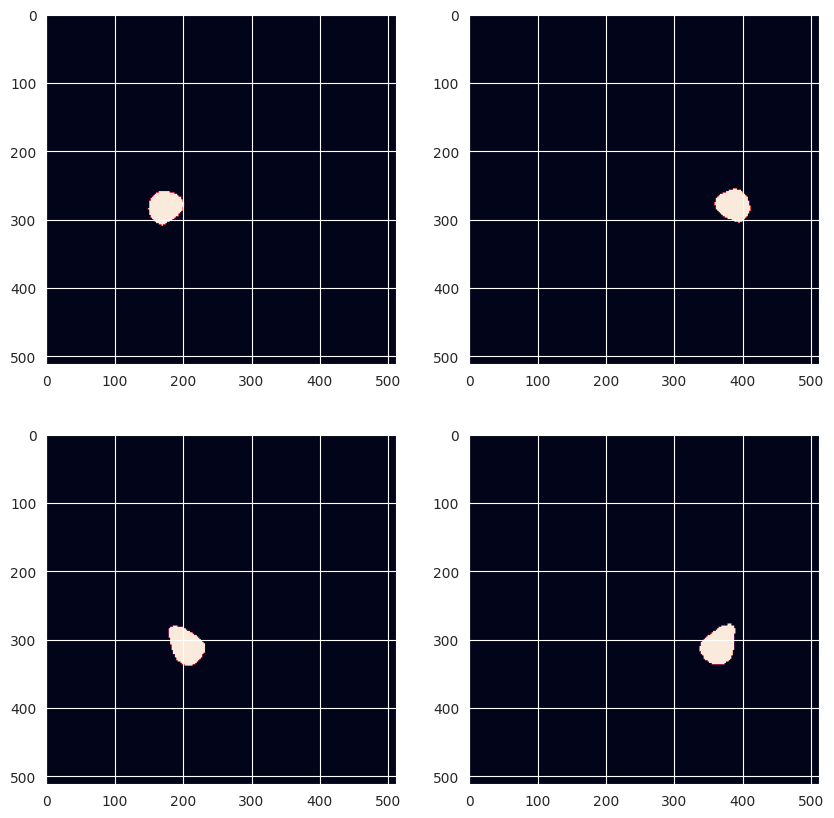

In [28]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))
ax[0, 0].imshow(left_knee[int(left_knee.shape[0] * .25)])
ax[0, 1].imshow(right_knee[int(right_knee.shape[0] * .25)])
ax[1, 0].imshow(left_knee[int(left_knee.shape[0] * .75)])
ax[1, 1].imshow(right_knee[int(right_knee.shape[0] * .75)])
plt.show()

In [29]:
left_ankle_tibia, right_ankle_tibia = split_masks(np.where(ankle == 1, 1, 0))
left_ankle_fibula, right_ankle_fibula = split_masks(np.where(ankle == 2, 1, 0))
left_ankle = left_ankle_tibia + np.where(left_ankle_fibula == 1, 2, 0)
right_ankle = right_ankle_tibia + np.where(right_ankle_fibula == 1, 2, 0)

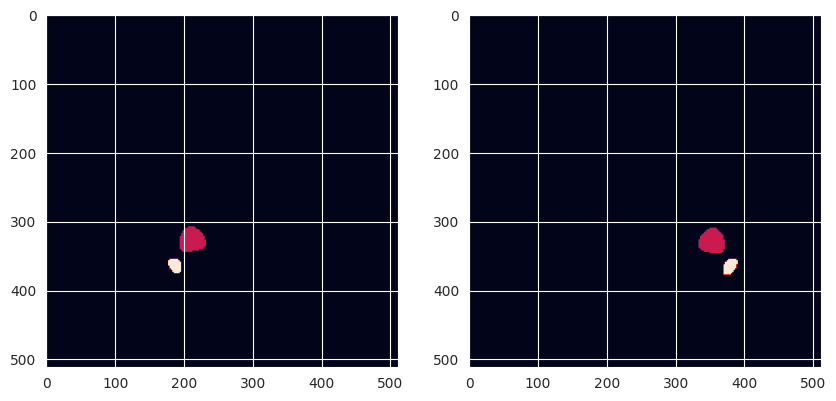

In [30]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
ax[0].imshow(left_ankle[int(left_ankle.shape[0] * .5)])
ax[1].imshow(right_ankle[int(right_ankle.shape[0] * .5)])
plt.show()

In [31]:
from morphometry.femur import calculate_femoral_torsion
from morphometry.tibia import calculate_tibial_torsion

13.995897175381781

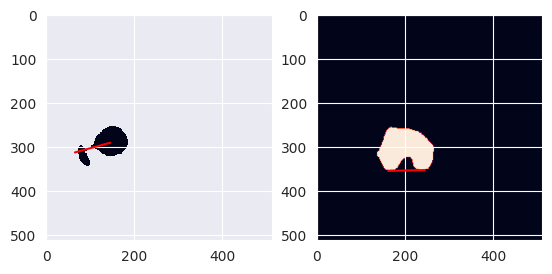

In [32]:
angle, fig = calculate_femoral_torsion(left_hip, left_knee, side='left', isotropic=True, plot=True)
angle

17.665424401022623

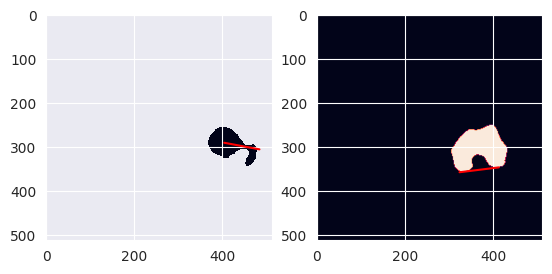

In [33]:
angle, fig = calculate_femoral_torsion(right_hip, right_knee, side='right', isotropic=True, plot=True)
angle

38.31666306701236

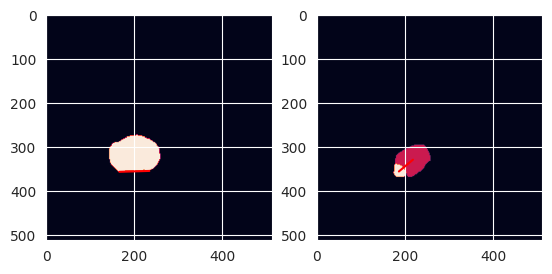

In [34]:
angle, fig = calculate_tibial_torsion(left_knee, left_ankle, tibia_label_knee=2, tibia_label_ankle=1, fibula_label=2, side='left', plot=True)
angle

48.76432007463558

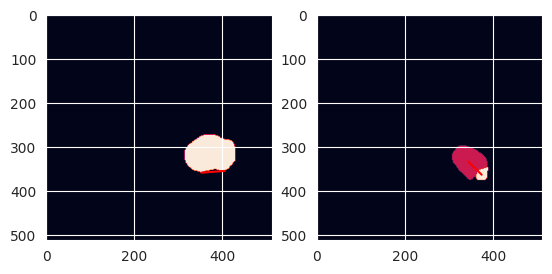

In [35]:
angle, fig = calculate_tibial_torsion(right_knee, right_ankle, tibia_label_knee=2, tibia_label_ankle=1, fibula_label=2, side='right', plot=True)
angle